In [1]:
from torchvision.models import resnet50, ResNet50_Weights
from torch import nn
import torch

weights = ResNet50_Weights.DEFAULT
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [2]:
from transform_dataset import FashionDataset
from torchvision import transforms as T
from pathlib import Path

project_root = Path.cwd().resolve().parent
csv_path = project_root / "data" / "processed" / "styles_processed.csv"
images_path = project_root / "data" / "raw" / "images"

image_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),  # Converts HWC PIL image to CHW tensor.
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = FashionDataset(csv_file=str(csv_path),image_dir=str(images_path), transform=image_transforms)

image, gender, article, color, usage = train_dataset[0]
print(image.shape)
print(image.dtype)
print(gender)
print(article)

ModuleNotFoundError: No module named 'transform_dataset'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


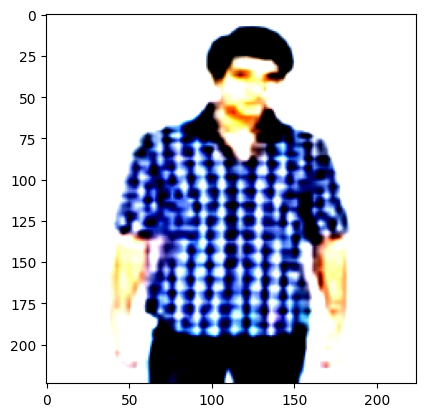

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image.permute(1,2,0)) # height, width, channel


In [ ]:
model = resnet50(weights=weights)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [ ]:
model.fc = nn.Identity()

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
dummy = torch.randn(1, 3, 224, 224)
features = model(dummy)
print(features.shape)

torch.Size([1, 2048])


In [ ]:
import torch
import torch.nn as nn

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)


class MultiTaskFashionModel(nn.Module):

    def __init__(
        self,
        num_gender_classes,
        num_article_classes,
        num_color_classes,
        num_usage_classes,
        freeze_backbone=True
    ):

        super().__init__()
        weights = ResNet50_Weights.DEFAULT
        self.backbone = resnet50(weights=weights)

        feature_size = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.gender_head = self._create_head(
            feature_size,
            num_gender_classes
        )

        self.article_head = self._create_head(
            feature_size,
            num_article_classes
        )

        self.color_head = self._create_head(
            feature_size,
            num_color_classes
        )

        self.usage_head = self._create_head(
            feature_size,
            num_usage_classes
        )

    def _create_head(self, input_features, output_classes):
        return nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_classes)
        )

    def forward(self, x):

        return {
          "gender": self.gender_head(features),
          "article": self.article_head(features),
          "color": self.color_head(features),
          "usage": self.usage_head(features)
        }

In [2]:
from torchvision.models import resnet18, ResNet18_Weights
from torch import nn
import torch

mode1_1_weights = ResNet18_Weights.DEFAULT
model_1_auto_transforms = mode1_1_weights.transforms()
model_1_auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [3]:
model_1 = resnet18(weights=mode1_1_weights)
print(model_1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta